# 05 - Segments, Recovery Scoring, and Next Best Actions

In this notebook, we turn the churn model and engineered business features into customer segments and action recommendations.

The goal is to create a retention-ready customer table that can help a loyalty team decide:
- who is at risk
- who is worth prioritizing
- why they are at risk
- what action should be taken next

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
# Connecting notebook to project folders

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path("/content/drive/MyDrive/LoyaltyRadar")

PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "data" / "outputs"
FIGURE_DIR = BASE_DIR / "reports" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [3]:
# Loading final customer-level feature dataset

df = pd.read_csv(PROCESSED_DIR / "03_final_customer_features.csv")

print("Dataset shape:", df.shape)
print("Unique customers:", df["loyalty_number"].nunique())

display(df.head())

Dataset shape: (16737, 50)
Unique customers: 16737


,loyalty_number,target_churn,behavioral_churn,formal_churn,churn_status_group,months_present,total_flights,active_months,inactive_months,active_month_rate,avg_flights_per_active_month,total_distance,flights_last_3m,flights_last_6m,points_accumulated_last_6m,points_redeemed_last_6m,inactive_last_3m,inactive_last_6m,flights_first_half_2018,flights_second_half_2018,flight_drop,flight_drop_pct,sharp_drop_flag,q1_flights,q2_flights,q3_flights,q4_flights,seasonality_ratio,seasonal_flag,total_points_accumulated,total_points_redeemed,redemption_months,has_redeemed,redemption_rate,points_collector_flag,clv,clv_tier,high_value_flag,premium_value_flag,loyalty_value_at_risk,retention_priority_score,priority_band,loyalty_card,province,city,gender,education,salary_imputed,salary_missing,enrollment_type
0,100018,0,0,0,Healthy Active,24,46,18,6,0.750000,2.555556,81190,10,17,36377.0,385,0,0,5.0,17.0,-12.0,-2.400000,0,9,3,16,18,0.391304,0,81190.0,1513,3,True,0.018635,1,7919.20,High Value,1,0,0.0,10,Low Priority,Aurora,Alberta,Edmonton,Female,Bachelor,92552.0,0,Standard
1,100102,0,0,0,Healthy Active,24,51,17,7,0.708333,3.000000,68918,11,17,18795.0,0,0,0,9.0,17.0,-8.0,-0.888889,0,10,10,13,18,0.352941,0,68918.0,1195,2,True,0.017339,1,2887.74,Low Value,0,0,0.0,10,Low Priority,Nova,Ontario,Toronto,Male,College,73455.0,1,Standard
2,100140,0,0,0,Healthy Active,24,47,17,7,0.708333,2.764706,72856,3,11,20488.0,0,0,0,14.0,11.0,3.0,0.214286,0,9,13,15,10,0.319149,0,72856.0,593,1,True,0.008139,1,2838.07,Low Value,0,0,0.0,10,Low Priority,Nova,British Columbia,Dawson Creek,Female,College,73455.0,1,Standard
3,100214,0,0,0,Healthy Active,24,22,9,15,0.375000,2.444444,38236,3,9,14321.0,0,0,0,3.0,9.0,-6.0,-2.000000,0,3,2,8,9,0.409091,0,38236.0,861,2,True,0.022518,0,4170.57,Mid Value,0,0,0.0,0,Low Priority,Star,British Columbia,Vancouver,Male,Bachelor,63253.0,0,Standard
4,100272,0,0,0,Healthy Active,24,37,13,11,0.541667,2.846154,54997,4,9,16412.0,0,0,0,8.0,9.0,-1.0,-0.125000,0,7,15,7,8,0.405405,0,54997.0,1007,2,True,0.018310,1,6622.05,High Value,1,0,0.0,10,Low Priority,Star,Ontario,Toronto,Female,Bachelor,91163.0,0,Standard


In [4]:
# Creating key customer segment flags

segments = df.copy()

segments["premium_drifter_flag"] = (
    (segments["premium_value_flag"] == 1) &
    (segments["behavioral_churn"] == 1)
).astype(int)

segments["points_collector_at_risk_flag"] = (
    (segments["points_collector_flag"] == 1) &
    (segments["behavioral_churn"] == 1)
).astype(int)

segments["travel_break_risk_flag"] = (
    (segments["sharp_drop_flag"] == 1) &
    (segments["behavioral_churn"] == 1)
).astype(int)

segments["seasonal_risk_flag"] = (
    (segments["seasonal_flag"] == 1) &
    (segments["behavioral_churn"] == 1)
).astype(int)

segments["silent_risk_flag"] = (
    (segments["churn_status_group"] == "Silent Risk")
).astype(int)

print("Segment flags created successfully.")

Segment flags created successfully.


In [5]:
# Summarizing important customer segments

segment_summary = pd.DataFrame({
    "segment": [
        "Premium Drifters",
        "Points Collectors at Risk",
        "Travel Break Risk",
        "Seasonal Risk",
        "Silent Risk"
    ],
    "customers": [
        segments["premium_drifter_flag"].sum(),
        segments["points_collector_at_risk_flag"].sum(),
        segments["travel_break_risk_flag"].sum(),
        segments["seasonal_risk_flag"].sum(),
        segments["silent_risk_flag"].sum()
    ],
    "total_clv": [
        segments.loc[segments["premium_drifter_flag"] == 1, "clv"].sum(),
        segments.loc[segments["points_collector_at_risk_flag"] == 1, "clv"].sum(),
        segments.loc[segments["travel_break_risk_flag"] == 1, "clv"].sum(),
        segments.loc[segments["seasonal_risk_flag"] == 1, "clv"].sum(),
        segments.loc[segments["silent_risk_flag"] == 1, "clv"].sum()
    ],
    "avg_clv": [
        segments.loc[segments["premium_drifter_flag"] == 1, "clv"].mean(),
        segments.loc[segments["points_collector_at_risk_flag"] == 1, "clv"].mean(),
        segments.loc[segments["travel_break_risk_flag"] == 1, "clv"].mean(),
        segments.loc[segments["seasonal_risk_flag"] == 1, "clv"].mean(),
        segments.loc[segments["silent_risk_flag"] == 1, "clv"].mean()
    ],
    "formal_churn_rate": [
        segments.loc[segments["premium_drifter_flag"] == 1, "formal_churn"].mean(),
        segments.loc[segments["points_collector_at_risk_flag"] == 1, "formal_churn"].mean(),
        segments.loc[segments["travel_break_risk_flag"] == 1, "formal_churn"].mean(),
        segments.loc[segments["seasonal_risk_flag"] == 1, "formal_churn"].mean(),
        segments.loc[segments["silent_risk_flag"] == 1, "formal_churn"].mean()
    ]
}).round(3)

display(segment_summary)

,segment,customers,total_clv,avg_clv,formal_churn_rate
0,Premium Drifters,613,10567476.08,17238.950,0.719
1,Points Collectors at Risk,25,204398.86,8175.954,0.680
2,Travel Break Risk,271,2021888.58,7460.843,0.786
3,Seasonal Risk,255,2127920.99,8344.788,0.922
4,Silent Risk,727,5816237.99,8000.327,0.000


Observation:
Rule-based customer segments provide interpretable retention groups. Premium Drifters are the highest-value segment, with 613 customers and around 10.57 million CLV. Silent Risk customers are especially useful for proactive retention because they have not formally churned but already show behavioral inactivity. Travel Break Risk and Seasonal Risk segments show very high formal churn rates, suggesting that sudden activity drops and missed seasonal behavior are strong warning signals. These segments can overlap, so they should be used as explainable tags rather than mutually exclusive clusters.

In [6]:
# Creating one primary segment per customer

def assign_primary_segment(row):
    if row["premium_drifter_flag"] == 1:
        return "Premium Drifter"
    elif row["silent_risk_flag"] == 1:
        return "Silent Risk"
    elif row["travel_break_risk_flag"] == 1:
        return "Travel Break Risk"
    elif row["seasonal_risk_flag"] == 1:
        return "Seasonal Risk"
    elif row["points_collector_at_risk_flag"] == 1:
        return "Points Collector at Risk"
    else:
        return "Healthy / Monitor"

segments["primary_segment"] = segments.apply(assign_primary_segment, axis=1)

primary_segment_summary = (
    segments
    .groupby("primary_segment")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        total_clv=("clv", "sum"),
        formal_churn_rate=("formal_churn", "mean"),
        behavioral_churn_rate=("behavioral_churn", "mean"),
        avg_priority_score=("retention_priority_score", "mean")
    )
    .round(3)
    .sort_values("avg_priority_score", ascending=False)
)

display(primary_segment_summary)

,customers,avg_clv,total_clv,formal_churn_rate,behavioral_churn_rate,avg_priority_score
primary_segment,,,,,,
Premium Drifter,613,17238.950,1.056748e+07,0.719,1.000,72.178
Travel Break Risk,162,5027.951,8.145281e+05,1.000,1.000,66.327
Points Collector at Risk,3,4296.647,1.288994e+04,1.000,1.000,60.000
Seasonal Risk,146,4889.737,7.139016e+05,1.000,1.000,55.000
Silent Risk,555,5142.900,2.854310e+06,0.000,1.000,51.532
Healthy / Monitor,15258,7782.610,1.187471e+08,0.086,0.065,13.230


Observation:
Primary segmentation assigns each customer to one main retention segment using a priority order. Premium Drifters are the most valuable risk group, with 613 customers and around 10.57 million CLV. Silent Risk customers are especially important for proactive retention because they have not formally churned but are already behaviorally inactive. Travel Break Risk and Seasonal Risk are smaller groups but show very high churn rates after priority assignment. These primary segments make the results easier for business teams to interpret and act on.

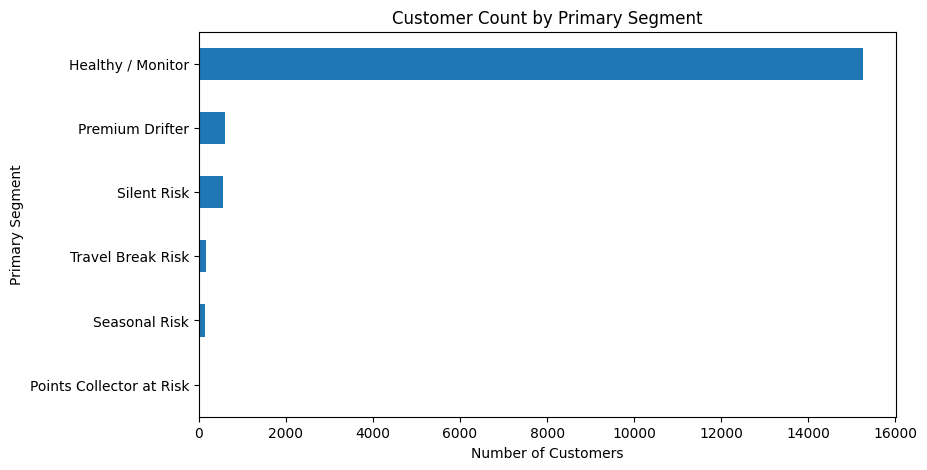

In [7]:
# Plotting primary segment customer counts

primary_segment_summary["customers"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Customer Count by Primary Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Primary Segment")
plt.show()

Higher CLV + points collector + not formally churned + some past activity = higher recovery potential

In [8]:
# Creating recovery potential score

segments["recovery_potential_score"] = (
    segments["high_value_flag"] * 20 +
    segments["premium_value_flag"] * 20 +
    segments["points_collector_flag"] * 15 +
    (segments["formal_churn"] == 0).astype(int) * 20 +
    (segments["active_month_rate"] > 0.25).astype(int) * 15 +
    (segments["total_points_redeemed"] > 0).astype(int) * 10
)

segments["recovery_potential_score"] = segments["recovery_potential_score"].clip(0, 100)

display(
    segments[
        ["loyalty_number", "primary_segment", "clv", "formal_churn",
         "active_month_rate", "points_collector_flag", "total_points_redeemed",
         "recovery_potential_score"]
    ]
    .sort_values("recovery_potential_score", ascending=False)
    .head(20)
)

,loyalty_number,primary_segment,clv,formal_churn,active_month_rate,points_collector_flag,total_points_redeemed,recovery_potential_score
16712,998580,Healthy / Monitor,9767.94,0,0.791667,1,1121,100
16682,996997,Healthy / Monitor,9338.08,0,0.666667,1,426,100
16679,996900,Healthy / Monitor,27937.75,0,0.791667,1,1281,100
16661,996086,Healthy / Monitor,9047.12,0,0.458333,1,534,100
16654,995695,Healthy / Monitor,16313.68,0,0.708333,1,603,100
16651,995527,Healthy / Monitor,14316.85,0,0.583333,1,558,100
16594,991924,Healthy / Monitor,14120.04,0,0.750000,1,540,100
16532,988691,Healthy / Monitor,26122.13,0,0.416667,1,538,100
16525,988345,Healthy / Monitor,14134.35,0,0.666667,1,439,100
16518,988043,Healthy / Monitor,23020.89,0,0.416667,1,440,100


In [9]:
# Summarizing recovery potential by primary segment

recovery_summary = (
    segments
    .groupby("primary_segment")
    .agg(
        customers=("loyalty_number", "count"),
        avg_recovery_potential=("recovery_potential_score", "mean"),
        avg_priority_score=("retention_priority_score", "mean"),
        avg_clv=("clv", "mean"),
        formal_churn_rate=("formal_churn", "mean")
    )
    .round(3)
    .sort_values("avg_recovery_potential", ascending=False)
)

display(recovery_summary)

,customers,avg_recovery_potential,avg_priority_score,avg_clv,formal_churn_rate
primary_segment,,,,,
Healthy / Monitor,15258,58.359,13.230,7782.610,0.086
Premium Drifter,613,48.605,72.178,17238.950,0.719
Points Collector at Risk,3,40.000,60.000,4296.647,1.000
Silent Risk,555,29.685,51.532,5142.900,0.000
Travel Break Risk,162,20.463,66.327,5027.951,1.000
Seasonal Risk,146,10.274,55.000,4889.737,1.000


Observation:
The initial recovery potential score gives high scores to Healthy / Monitor customers because they are active, not formally churned, and often show loyalty engagement. However, for retention planning, recovery potential is most useful among at-risk customers, not healthy customers. Therefore, the score should be adjusted so that healthy customers are not prioritized for recovery campaigns.

In [10]:
# Creating improved recovery potential score focused on at-risk customers

segments["at_risk_flag"] = (
    (segments["behavioral_churn"] == 1) |
    (segments["priority_band"].isin(["High Priority", "Critical Priority"]))
).astype(int)

segments["recovery_potential_score_v2"] = (
    segments["high_value_flag"] * 20 +
    segments["premium_value_flag"] * 20 +
    segments["points_collector_flag"] * 15 +
    (segments["formal_churn"] == 0).astype(int) * 25 +
    (segments["active_month_rate"] > 0.25).astype(int) * 10 +
    (segments["total_points_redeemed"] > 0).astype(int) * 10
)

segments["recovery_potential_score_v2"] = (
    segments["recovery_potential_score_v2"] * segments["at_risk_flag"]
)

segments["recovery_potential_score_v2"] = segments["recovery_potential_score_v2"].clip(0, 100)

display(
    segments[
        ["loyalty_number", "primary_segment", "priority_band", "clv", "formal_churn",
         "behavioral_churn", "active_month_rate", "points_collector_flag",
         "recovery_potential_score_v2"]
    ]
    .sort_values("recovery_potential_score_v2", ascending=False)
    .head(20)
)

,loyalty_number,primary_segment,priority_band,clv,formal_churn,behavioral_churn,active_month_rate,points_collector_flag,recovery_potential_score_v2
5685,407933,Healthy / Monitor,High Priority,18680.99,0,0,0.541667,1,100
574,131253,Premium Drifter,Critical Priority,19327.87,0,1,0.458333,1,100
6886,471098,Healthy / Monitor,High Priority,13211.01,0,0,0.625000,1,100
8769,571992,Healthy / Monitor,High Priority,33053.27,0,0,0.708333,1,100
8356,549715,Healthy / Monitor,High Priority,13727.80,0,0,0.625000,1,100
223,112142,Premium Drifter,Critical Priority,16272.74,0,1,0.416667,1,100
8690,567420,Healthy / Monitor,High Priority,24980.23,0,0,0.750000,1,100
4184,326603,Healthy / Monitor,High Priority,11776.00,0,0,0.625000,1,100
9454,607588,Healthy / Monitor,High Priority,12885.79,0,0,0.363636,1,100
13994,850034,Healthy / Monitor,High Priority,9112.27,0,0,0.666667,1,100


In [11]:
# Summarizing improved recovery potential by primary segment

recovery_summary_v2 = (
    segments
    .groupby("primary_segment")
    .agg(
        customers=("loyalty_number", "count"),
        avg_recovery_potential=("recovery_potential_score_v2", "mean"),
        avg_priority_score=("retention_priority_score", "mean"),
        avg_clv=("clv", "mean"),
        formal_churn_rate=("formal_churn", "mean"),
        behavioral_churn_rate=("behavioral_churn", "mean")
    )
    .round(3)
    .sort_values("avg_recovery_potential", ascending=False)
)

display(recovery_summary_v2)

,customers,avg_recovery_potential,avg_priority_score,avg_clv,formal_churn_rate,behavioral_churn_rate
primary_segment,,,,,,
Premium Drifter,613,49.600,72.178,17238.950,0.719,1.000
Points Collector at Risk,3,35.000,60.000,4296.647,1.000,1.000
Silent Risk,555,34.207,51.532,5142.900,0.000,1.000
Travel Break Risk,162,17.747,66.327,5027.951,1.000,1.000
Seasonal Risk,146,10.274,55.000,4889.737,1.000,1.000
Healthy / Monitor,15258,0.939,13.230,7782.610,0.086,0.065


Observation:
The improved recovery potential score focuses only on at-risk customers. This makes the score more useful for retention planning because Healthy / Monitor customers are no longer ranked highly for recovery campaigns. Premium Drifters have the highest average recovery potential because they combine high value with inactivity. Silent Risk customers also show meaningful recovery potential because they are behaviorally inactive but have not formally churned yet.

In [12]:
# Creating recovery potential bands

def create_recovery_band(score):
    if score >= 70:
        return "High Recovery Potential"
    elif score >= 40:
        return "Medium Recovery Potential"
    elif score > 0:
        return "Low Recovery Potential"
    else:
        return "No Recovery Action Needed"

segments["recovery_potential_band"] = segments["recovery_potential_score_v2"].apply(create_recovery_band)

recovery_band_summary = (
    segments
    .groupby("recovery_potential_band")
    .agg(
        customers=("loyalty_number", "count"),
        avg_recovery_score=("recovery_potential_score_v2", "mean"),
        avg_priority_score=("retention_priority_score", "mean"),
        avg_clv=("clv", "mean"),
        total_clv=("clv", "sum"),
        formal_churn_rate=("formal_churn", "mean"),
        behavioral_churn_rate=("behavioral_churn", "mean")
    )
    .round(3)
    .sort_values("avg_recovery_score", ascending=False)
)

display(recovery_band_summary)

,customers,avg_recovery_score,avg_priority_score,avg_clv,total_clv,formal_churn_rate,behavioral_churn_rate
recovery_potential_band,,,,,,,
High Recovery Potential,76,88.158,57.171,16211.360,1.232063e+06,0.066,0.289
Medium Recovery Potential,851,48.143,66.234,14311.648,1.217921e+07,0.563,0.984
Low Recovery Potential,975,21.056,52.590,5339.112,5.205635e+06,0.652,1.000
No Recovery Action Needed,14835,0.000,12.246,7758.224,1.150933e+08,0.064,0.043


Observation:
Recovery potential bands help separate at-risk customers by how worth recovering they may be. The High Recovery Potential group is small, with 76 customers, but has high average CLV and low formal churn rate, making it a strong candidate for personalized retention. The Medium Recovery Potential group contains 851 customers and over 12 million CLV, making it the largest business opportunity for targeted campaigns. Low Recovery Potential customers are highly inactive and have higher formal churn, so they may be better suited for low-cost automated campaigns.

In [13]:
# Creating next best action recommendations

def assign_next_best_action(row):
    if row["primary_segment"] == "Premium Drifter":
        if row["recovery_potential_score_v2"] >= 40:
            return "Personalized premium win-back offer"
        else:
            return "High-value reactivation email"

    elif row["primary_segment"] == "Silent Risk":
        if row["recovery_potential_score_v2"] >= 40:
            return "Early retention call or targeted offer"
        else:
            return "Gentle re-engagement reminder"

    elif row["primary_segment"] == "Travel Break Risk":
        return "Travel pattern break alert with limited-time offer"

    elif row["primary_segment"] == "Seasonal Risk":
        return "Seasonal timing reminder before peak travel period"

    elif row["primary_segment"] == "Points Collector at Risk":
        return "Points redemption nudge"

    else:
        return "Monitor only"

segments["next_best_action"] = segments.apply(assign_next_best_action, axis=1)

display(
    segments[
        ["loyalty_number", "primary_segment", "priority_band",
         "recovery_potential_band", "clv", "retention_priority_score",
         "recovery_potential_score_v2", "next_best_action"]
    ]
    .sort_values(["retention_priority_score", "recovery_potential_score_v2"], ascending=False)
    .head(20)
)

,loyalty_number,primary_segment,priority_band,recovery_potential_band,clv,retention_priority_score,recovery_potential_score_v2,next_best_action
223,112142,Premium Drifter,Critical Priority,High Recovery Potential,16272.74,95,100,Personalized premium win-back offer
574,131253,Premium Drifter,Critical Priority,High Recovery Potential,19327.87,95,100,Personalized premium win-back offer
3832,307047,Premium Drifter,Critical Priority,High Recovery Potential,13211.01,95,75,Personalized premium win-back offer
7184,486708,Premium Drifter,Critical Priority,High Recovery Potential,23295.06,95,75,Personalized premium win-back offer
15026,907077,Premium Drifter,Critical Priority,High Recovery Potential,10208.93,95,75,Personalized premium win-back offer
8267,545410,Premium Drifter,Critical Priority,Medium Recovery Potential,13918.53,95,65,Personalized premium win-back offer
6597,455758,Premium Drifter,Critical Priority,High Recovery Potential,10357.51,90,75,Personalized premium win-back offer
340,118376,Premium Drifter,Critical Priority,Medium Recovery Potential,20455.25,90,50,Personalized premium win-back offer
390,121351,Premium Drifter,Critical Priority,Medium Recovery Potential,28421.57,90,50,Personalized premium win-back offer
10627,670836,Premium Drifter,Critical Priority,Medium Recovery Potential,19079.10,90,50,Personalized premium win-back offer


In [14]:
# Summarizing next best action recommendations

action_summary = (
    segments
    .groupby("next_best_action")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        total_clv=("clv", "sum"),
        avg_priority_score=("retention_priority_score", "mean"),
        avg_recovery_score=("recovery_potential_score_v2", "mean"),
        formal_churn_rate=("formal_churn", "mean"),
        behavioral_churn_rate=("behavioral_churn", "mean")
    )
    .round(3)
    .sort_values("avg_priority_score", ascending=False)
)

display(action_summary)

,customers,avg_clv,total_clv,avg_priority_score,avg_recovery_score,formal_churn_rate,behavioral_churn_rate
next_best_action,,,,,,,
Personalized premium win-back offer,613,17238.950,1.056748e+07,72.178,49.600,0.719,1.000
Travel pattern break alert with limited-time offer,162,5027.951,8.145281e+05,66.327,17.747,1.000,1.000
Points redemption nudge,3,4296.647,1.288994e+04,60.000,35.000,1.000,1.000
Seasonal timing reminder before peak travel period,146,4889.737,7.139016e+05,55.000,10.274,1.000,1.000
Early retention call or targeted offer,216,7096.671,1.532881e+06,53.056,47.731,0.000,1.000
Gentle re-engagement reminder,339,3898.020,1.321429e+06,50.560,25.590,0.000,1.000
Monitor only,15258,7782.610,1.187471e+08,13.230,0.939,0.086,0.065


Observation:
The Next Best Action Engine converts analytical segments into campaign-ready recommendations. Premium Drifters receive personalized premium win-back offers because they combine high value with high inactivity risk. Silent Risk customers are split into stronger targeted offers or lighter re-engagement reminders based on recovery potential. Travel Break and Seasonal Risk customers receive more context-specific actions. This makes the system more actionable than a simple churn probability model because it tells the business what to do next.

In [15]:
# Creating final campaign-ready customer table

campaign_columns = [
    "loyalty_number",
    "primary_segment",
    "next_best_action",
    "priority_band",
    "retention_priority_score",
    "recovery_potential_band",
    "recovery_potential_score_v2",
    "clv",
    "loyalty_value_at_risk",
    "clv_tier",
    "loyalty_card",
    "province",
    "city",
    "behavioral_churn",
    "formal_churn",
    "churn_status_group",
    "active_month_rate",
    "inactive_months",
    "flights_last_6m",
    "points_collector_flag",
    "sharp_drop_flag",
    "seasonal_flag"
]

campaign_table = segments[campaign_columns].copy()

campaign_table = campaign_table.sort_values(
    ["retention_priority_score", "recovery_potential_score_v2", "clv"],
    ascending=False
)

print("Campaign table shape:", campaign_table.shape)
display(campaign_table.head(20))

Campaign table shape: (16737, 22)


,loyalty_number,primary_segment,next_best_action,priority_band,retention_priority_score,recovery_potential_band,recovery_potential_score_v2,clv,loyalty_value_at_risk,clv_tier,loyalty_card,province,city,behavioral_churn,formal_churn,churn_status_group,active_month_rate,inactive_months,flights_last_6m,points_collector_flag,sharp_drop_flag,seasonal_flag
574,131253,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,High Recovery Potential,100,19327.87,19327.87,Premium Value,Aurora,Ontario,Sudbury,1,0,Silent Risk,0.458333,13,0,1,1,0
223,112142,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,High Recovery Potential,100,16272.74,16272.74,Premium Value,Aurora,Ontario,Thunder Bay,1,0,Silent Risk,0.416667,14,0,1,1,0
7184,486708,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,High Recovery Potential,75,23295.06,23295.06,Premium Value,Star,Quebec,Montreal,1,1,Confirmed Churn,0.583333,10,0,1,1,0
3832,307047,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,High Recovery Potential,75,13211.01,13211.01,Premium Value,Aurora,Manitoba,Winnipeg,1,1,Confirmed Churn,0.458333,13,0,1,1,0
15026,907077,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,High Recovery Potential,75,10208.93,10208.93,Premium Value,Aurora,Ontario,Trenton,1,1,Confirmed Churn,0.458333,13,0,1,1,0
8267,545410,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,Medium Recovery Potential,65,13918.53,13918.53,Premium Value,Aurora,Ontario,Toronto,1,1,Confirmed Churn,0.416667,14,0,1,1,0
6597,455758,Premium Drifter,Personalized premium win-back offer,Critical Priority,90,High Recovery Potential,75,10357.51,10357.51,Premium Value,Aurora,Ontario,Toronto,1,0,Silent Risk,0.208333,19,0,0,1,1
390,121351,Premium Drifter,Personalized premium win-back offer,Critical Priority,90,Medium Recovery Potential,50,28421.57,28421.57,Premium Value,Aurora,Ontario,Toronto,1,1,Confirmed Churn,0.272727,8,0,0,1,1
340,118376,Premium Drifter,Personalized premium win-back offer,Critical Priority,90,Medium Recovery Potential,50,20455.25,20455.25,Premium Value,Aurora,British Columbia,Kelowna,1,1,Confirmed Churn,0.083333,22,0,0,1,1
10627,670836,Premium Drifter,Personalized premium win-back offer,Critical Priority,90,Medium Recovery Potential,50,19079.10,19079.10,Premium Value,Star,Quebec,Montreal,1,1,Confirmed Churn,0.125000,21,0,0,1,1


In [16]:
# Creating campaign-level action summary

campaign_action_summary = (
    campaign_table
    .groupby("next_best_action")
    .agg(
        customers=("loyalty_number", "count"),
        total_clv=("clv", "sum"),
        total_value_at_risk=("loyalty_value_at_risk", "sum"),
        avg_priority_score=("retention_priority_score", "mean"),
        avg_recovery_score=("recovery_potential_score_v2", "mean"),
        behavioral_churn_rate=("behavioral_churn", "mean"),
        formal_churn_rate=("formal_churn", "mean")
    )
    .round(3)
    .sort_values("total_value_at_risk", ascending=False)
)

display(campaign_action_summary)

,customers,total_clv,total_value_at_risk,avg_priority_score,avg_recovery_score,behavioral_churn_rate,formal_churn_rate
next_best_action,,,,,,,
Personalized premium win-back offer,613,1.056748e+07,10567476.08,72.178,49.600,1.000,0.719
Monitor only,15258,1.187471e+08,5099352.57,13.230,0.939,0.065,0.086
Early retention call or targeted offer,216,1.532881e+06,1532880.98,53.056,47.731,1.000,0.000
Gentle re-engagement reminder,339,1.321429e+06,1321428.63,50.560,25.590,1.000,0.000
Travel pattern break alert with limited-time offer,162,8.145281e+05,814528.12,66.327,17.747,1.000,1.000
Seasonal timing reminder before peak travel period,146,7.139016e+05,713901.55,55.000,10.274,1.000,1.000
Points redemption nudge,3,1.288994e+04,12889.94,60.000,35.000,1.000,1.000


In [17]:
# Improving next best action recommendations with fallback for untagged inactive customers

def assign_next_best_action_v2(row):
    if row["primary_segment"] == "Premium Drifter":
        if row["recovery_potential_score_v2"] >= 40:
            return "Personalized premium win-back offer"
        else:
            return "High-value reactivation email"

    elif row["primary_segment"] == "Silent Risk":
        if row["recovery_potential_score_v2"] >= 40:
            return "Early retention call or targeted offer"
        else:
            return "Gentle re-engagement reminder"

    elif row["primary_segment"] == "Travel Break Risk":
        return "Travel pattern break alert with limited-time offer"

    elif row["primary_segment"] == "Seasonal Risk":
        return "Seasonal timing reminder before peak travel period"

    elif row["primary_segment"] == "Points Collector at Risk":
        return "Points redemption nudge"

    elif row["behavioral_churn"] == 1:
        return "Low-cost automated reactivation"

    else:
        return "Monitor only"

segments["next_best_action_v2"] = segments.apply(assign_next_best_action_v2, axis=1)

action_summary_v2 = (
    segments
    .groupby("next_best_action_v2")
    .agg(
        customers=("loyalty_number", "count"),
        avg_clv=("clv", "mean"),
        total_clv=("clv", "sum"),
        total_value_at_risk=("loyalty_value_at_risk", "sum"),
        avg_priority_score=("retention_priority_score", "mean"),
        avg_recovery_score=("recovery_potential_score_v2", "mean"),
        formal_churn_rate=("formal_churn", "mean"),
        behavioral_churn_rate=("behavioral_churn", "mean")
    )
    .round(3)
    .sort_values("total_value_at_risk", ascending=False)
)

display(action_summary_v2)

,customers,avg_clv,total_clv,total_value_at_risk,avg_priority_score,avg_recovery_score,formal_churn_rate,behavioral_churn_rate
next_best_action_v2,,,,,,,,
Personalized premium win-back offer,613,17238.950,1.056748e+07,10567476.08,72.178,49.600,0.719,1.0
Low-cost automated reactivation,990,5150.861,5.099353e+06,5099352.57,50.000,8.697,1.000,1.0
Early retention call or targeted offer,216,7096.671,1.532881e+06,1532880.98,53.056,47.731,0.000,1.0
Gentle re-engagement reminder,339,3898.020,1.321429e+06,1321428.63,50.560,25.590,0.000,1.0
Travel pattern break alert with limited-time offer,162,5027.951,8.145281e+05,814528.12,66.327,17.747,1.000,1.0
Seasonal timing reminder before peak travel period,146,4889.737,7.139016e+05,713901.55,55.000,10.274,1.000,1.0
Points redemption nudge,3,4296.647,1.288994e+04,12889.94,60.000,35.000,1.000,1.0
Monitor only,14268,7965.216,1.136477e+08,0.00,10.678,0.401,0.023,0.0


Observation:
The first action summary showed that some behaviorally churned customers were still assigned to “Monitor only.” This was corrected by adding a fallback action called “Low-cost automated reactivation” for customers who are inactive but do not belong to the main high-priority segments. This makes the Next Best Action Engine safer because no customer with value at risk is ignored completely.

Observation:
After adding the fallback action, the Next Best Action Engine no longer leaves behaviorally churned customers in the Monitor Only group. Monitor Only now has zero value at risk and zero behavioral churn rate, while all inactive customers receive an appropriate retention action. This makes the campaign logic safer and more complete for business use.

In [18]:
# Creating final corrected campaign-ready customer table

campaign_columns_v2 = [
    "loyalty_number",
    "primary_segment",
    "next_best_action_v2",
    "priority_band",
    "retention_priority_score",
    "recovery_potential_band",
    "recovery_potential_score_v2",
    "clv",
    "loyalty_value_at_risk",
    "clv_tier",
    "loyalty_card",
    "province",
    "city",
    "behavioral_churn",
    "formal_churn",
    "churn_status_group",
    "active_month_rate",
    "inactive_months",
    "flights_last_6m",
    "points_collector_flag",
    "sharp_drop_flag",
    "seasonal_flag"
]

campaign_table_v2 = segments[campaign_columns_v2].copy()

campaign_table_v2 = campaign_table_v2.sort_values(
    ["retention_priority_score", "recovery_potential_score_v2", "clv"],
    ascending=False
)

print("Final campaign table shape:", campaign_table_v2.shape)
display(campaign_table_v2.head(20))

Final campaign table shape: (16737, 22)


,loyalty_number,primary_segment,next_best_action_v2,priority_band,retention_priority_score,recovery_potential_band,recovery_potential_score_v2,clv,loyalty_value_at_risk,clv_tier,loyalty_card,province,city,behavioral_churn,formal_churn,churn_status_group,active_month_rate,inactive_months,flights_last_6m,points_collector_flag,sharp_drop_flag,seasonal_flag
574,131253,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,High Recovery Potential,100,19327.87,19327.87,Premium Value,Aurora,Ontario,Sudbury,1,0,Silent Risk,0.458333,13,0,1,1,0
223,112142,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,High Recovery Potential,100,16272.74,16272.74,Premium Value,Aurora,Ontario,Thunder Bay,1,0,Silent Risk,0.416667,14,0,1,1,0
7184,486708,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,High Recovery Potential,75,23295.06,23295.06,Premium Value,Star,Quebec,Montreal,1,1,Confirmed Churn,0.583333,10,0,1,1,0
3832,307047,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,High Recovery Potential,75,13211.01,13211.01,Premium Value,Aurora,Manitoba,Winnipeg,1,1,Confirmed Churn,0.458333,13,0,1,1,0
15026,907077,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,High Recovery Potential,75,10208.93,10208.93,Premium Value,Aurora,Ontario,Trenton,1,1,Confirmed Churn,0.458333,13,0,1,1,0
8267,545410,Premium Drifter,Personalized premium win-back offer,Critical Priority,95,Medium Recovery Potential,65,13918.53,13918.53,Premium Value,Aurora,Ontario,Toronto,1,1,Confirmed Churn,0.416667,14,0,1,1,0
6597,455758,Premium Drifter,Personalized premium win-back offer,Critical Priority,90,High Recovery Potential,75,10357.51,10357.51,Premium Value,Aurora,Ontario,Toronto,1,0,Silent Risk,0.208333,19,0,0,1,1
390,121351,Premium Drifter,Personalized premium win-back offer,Critical Priority,90,Medium Recovery Potential,50,28421.57,28421.57,Premium Value,Aurora,Ontario,Toronto,1,1,Confirmed Churn,0.272727,8,0,0,1,1
340,118376,Premium Drifter,Personalized premium win-back offer,Critical Priority,90,Medium Recovery Potential,50,20455.25,20455.25,Premium Value,Aurora,British Columbia,Kelowna,1,1,Confirmed Churn,0.083333,22,0,0,1,1
10627,670836,Premium Drifter,Personalized premium win-back offer,Critical Priority,90,Medium Recovery Potential,50,19079.10,19079.10,Premium Value,Star,Quebec,Montreal,1,1,Confirmed Churn,0.125000,21,0,0,1,1


In [19]:
# Saving NB05 segmentation and action outputs

segments.to_csv(
    PROCESSED_DIR / "05_customer_segments_actions.csv",
    index=False
)

campaign_table_v2.to_csv(
    OUTPUT_DIR / "05_campaign_table.csv",
    index=False
)

segment_summary.to_csv(
    OUTPUT_DIR / "05_segment_summary_overlapping.csv",
    index=False
)

primary_segment_summary.to_csv(
    OUTPUT_DIR / "05_primary_segment_summary.csv"
)

recovery_summary_v2.to_csv(
    OUTPUT_DIR / "05_recovery_summary.csv"
)

recovery_band_summary.to_csv(
    OUTPUT_DIR / "05_recovery_band_summary.csv"
)

action_summary_v2.to_csv(
    OUTPUT_DIR / "05_action_summary.csv"
)

print("Saved NB05 outputs successfully.")
print("Campaign table saved at:", OUTPUT_DIR / "05_campaign_table.csv")

Saved NB05 outputs successfully.
Campaign table saved at: /content/drive/MyDrive/LoyaltyRadar/data/outputs/05_campaign_table.csv


In [20]:
# Summarizing Notebook 05 results

print("NB05 SUMMARY")
print("-" * 50)

print("Customer segmentation completed.")
print("Total customers:", segments["loyalty_number"].nunique())

print("\nPrimary segment distribution:")
print(segments["primary_segment"].value_counts())

print("\nNext best action distribution:")
print(segments["next_best_action_v2"].value_counts())

print("\nTop business metrics:")
print("Premium Drifters:", int(segments["premium_drifter_flag"].sum()))
print("Silent Risk customers:", int(segments["silent_risk_flag"].sum()))
print("Total value at risk:", round(segments["loyalty_value_at_risk"].sum(), 2))

print("\nCampaign table shape:", campaign_table_v2.shape)

print("\nNotebook 05 completed successfully.")

NB05 SUMMARY
--------------------------------------------------
Customer segmentation completed.
Total customers: 16737

Primary segment distribution:
primary_segment
Healthy / Monitor           15258
Premium Drifter               613
Silent Risk                   555
Travel Break Risk             162
Seasonal Risk                 146
Points Collector at Risk        3
Name: count, dtype: int64

Next best action distribution:
next_best_action_v2
Monitor only                                          14268
Low-cost automated reactivation                         990
Personalized premium win-back offer                     613
Gentle re-engagement reminder                           339
Early retention call or targeted offer                  216
Travel pattern break alert with limited-time offer      162
Seasonal timing reminder before peak travel period      146
Points redemption nudge                                   3
Name: count, dtype: int64

Top business metrics:
Premium Drifters: 613
